<a href="https://colab.research.google.com/github/riztikamerista/2025_PBO_TI1C/blob/main/Jobsheet3_VisiKomputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 1

Langkah 1. Setup & Generator Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models

# Generator 1 sample
def make_sample(img_size=64, min_r=5, max_r=20):
  r = np.random.randint(min_r, max_r + 1) # radius acak
  img = np.zeros((img_size, img_size), dtype=np.uint8)
  cx = np.random.randint(r, img_size - r) # center-x
  cy = np.random.randint(r, img_size - r) # center-y
  cv2.circle(img, (cx, cy), r, (255,), -1) # lingkaran putih terisi
  img = (img / 255.0).astype(np.float32)

  # 3-channel biar kompatibel CNN
  img3 = np.stack([img, img, img], axis=-1)
  return img3, float(r), (cx, cy)

Langkah 2. “Tebak Apa?” — Tampilkan Contoh Gambar TANPA Label

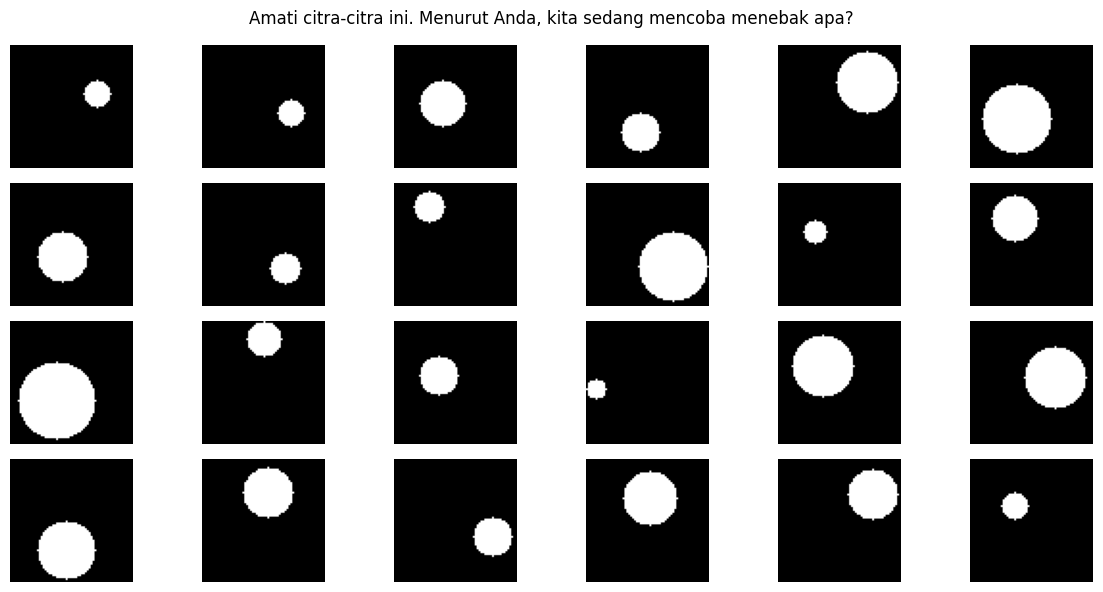

In [ ]:
# Buat 24 contoh untuk visualisasi
N_show = 24
samples = [make_sample() for _ in range(N_show)]
imgs = [s[0] for s in samples]
rads = [s[1] for s in samples]
centers = [s[2] for s in samples]

# Grid gambar tanpa label:
cols = 6
rows = N_show // cols
plt.figure(figsize=(12, 6))
for i in range(N_show):
  plt.subplot(rows, cols, i+1)
  plt.imshow(imgs[i].squeeze(), cmap='gray')
  plt.axis('off')

plt.suptitle("Amati citra-citra ini. Menurut Anda, kita sedang mencoba menebak apa?")
plt.tight_layout()
plt.show()

Langkah 3.	Buka Jawaban — Target yang Ingin Diprediksi

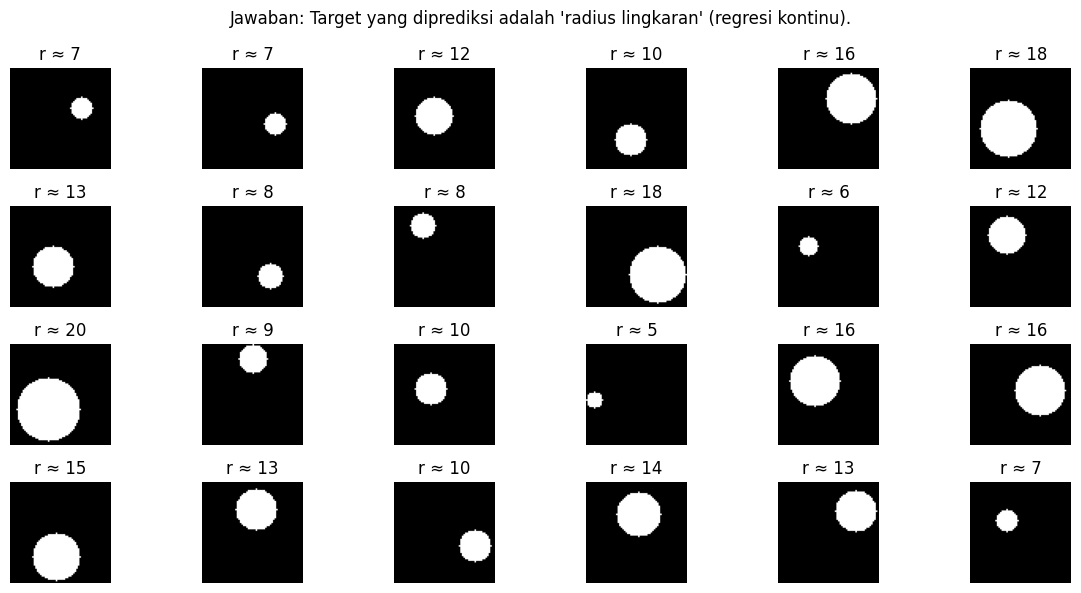

In [ ]:
# Tampilkan kembali, sekarang tampilkan radius (label) di judul tiap subplot
plt.figure(figsize=(12, 6))
for i in range(N_show):
  plt.subplot(rows, cols, i+1)
  plt.imshow(imgs[i].squeeze(), cmap='gray')
  plt.title(f"r ≈ {int(rads[i])}")
  plt.axis('off')
plt.suptitle("Jawaban: Target yang diprediksi adalah 'radius lingkaran' (regresi kontinu).")
plt.tight_layout()
plt.show()

Langkah 4.	(Opsional) Latih CNN Kecil untuk Memprediksi Radius

In [ ]:
# Siapkan dataset lebih besar untuk training
N = 3000
X, y, C = zip(*[make_sample()
for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# Model CNN sederhana
model = models.Sequential([ layers.Input((64,64,3)),
layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(), layers.Conv2D(64, 3, activation='relu'),
                            layers.MaxPooling2D(), layers.Conv2D(128, 3, activation='relu'),
                            layers.GlobalAveragePooling2D(), layers.Dense(64, activation='relu'), layers.Dense(1) # output regresi
                            ])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Xtr, ytr, validation_data=(Xte, yte),
                    epochs=12, batch_size=64, verbose=0)

# Evaluasi
y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = float(np.sqrt(np.mean((yte - y_pred)**2)))
r2 = r2_score(yte, y_pred)
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
MAE=0.972 | RMSE=1.181 | R²=0.938


Plot history & True vs Predicted

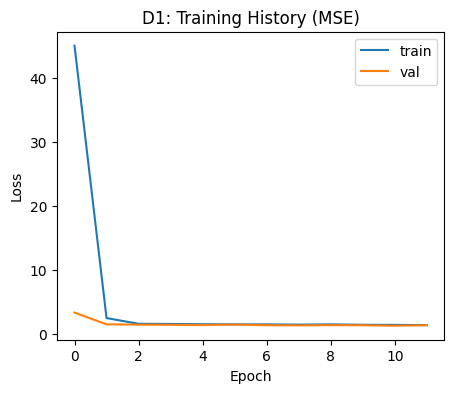

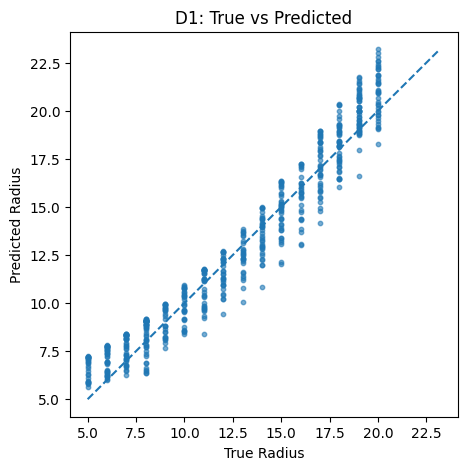

In [ ]:
# Plot loss
plt.figure(figsize=(5,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("D1: Training History (MSE)")
plt.xlabel("Epoch");
plt.ylabel("Loss");
plt.legend();
plt.show()

# Scatter True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(yte, y_pred, s=10, alpha=0.6)
lims = [min(yte.min(), y_pred.min()), max(yte.max(), y_pred.max())]
plt.plot(lims, lims, '--')
plt.xlabel("True Radius");
plt.ylabel("Predicted Radius")
plt.title("D1: True vs Predicted")
plt.show()

5.	Tantangan Mini (Opsional untuk Mahasiswa)

Ubah Rentang Radius (8–28)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models

# =============================
# Fungsi pembuat citra lingkaran
# =============================
def make_sample(img_size=64, min_r=8, max_r=28, noise=False):
    r = np.random.randint(min_r, max_r + 1)
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    cx = np.random.randint(r, img_size - r)
    cy = np.random.randint(r, img_size - r)
    cv2.circle(img, (cx, cy), r, (255,), -1)

    # Normalisasi
    img = (img / 255.0).astype(np.float32)

    # Tambahkan noise opsional
    if noise:
        # Gaussian noise
        img += np.random.normal(0, 0.05, img.shape)
        img = np.clip(img, 0, 1)
        # Sedikit blur
        img = cv2.GaussianBlur(img, (3, 3), 0)

    img3 = np.stack([img, img, img], axis=-1)
    return img3, float(r), (cx, cy)

# =============================
# Buat dataset radius lebih besar
# =============================
N = 3000
X, y, _ = zip(*[make_sample(min_r=8, max_r=28) for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# =============================
# Model CNN regresi sederhana
# =============================
model = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=10, batch_size=64, verbose=0)

# Evaluasi
y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = np.sqrt(np.mean((yte - y_pred)**2))
r2 = r2_score(yte, y_pred)
print(f"[Eksperimen 1: Radius 8–28] MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
[Eksperimen 1: Radius 8–28] MAE=0.765 | RMSE=0.962 | R²=0.975


Tambahkan Noise (Gaussian + Blur)

In [ ]:
# Dataset dengan noise
N = 3000
X, y, _ = zip(*[make_sample(noise=True) for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

model = tf.keras.models.clone_model(model)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=10, batch_size=64, verbose=0)

y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = np.sqrt(np.mean((yte - y_pred)**2))
r2 = r2_score(yte, y_pred)
print(f"[Eksperimen 2: Dengan Noise] MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
[Eksperimen 2: Dengan Noise] MAE=0.714 | RMSE=0.912 | R²=0.978


Multi-Output ([r, cx, cy])

In [ ]:
# Dataset multi-output
N = 3000
X, y_r, centers = zip(*[make_sample() for _ in range(N)])
y = np.array([[r, cx, cy] for r, (cx, cy) in zip(y_r, centers)], dtype=np.float32)
X = np.array(X, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

model_multi = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3)  # output [r, cx, cy]
])

model_multi.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model_multi.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=12, batch_size=64, verbose=0)

y_pred = model_multi.predict(Xte)
mae = mean_absolute_error(yte, y_pred)
rmse = np.sqrt(np.mean((yte - y_pred)**2))
r2 = r2_score(yte, y_pred)
print(f"[Eksperimen 3: Multi-output] MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

# Catatan: metrik seperti MAE & RMSE masih bisa dipakai karena semua output numerik kontinu.
# Bisa juga pakai Mean Euclidean Distance (MED) antar titik [r, cx, cy].

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
[Eksperimen 3: Multi-output] MAE=2.457 | RMSE=3.792 | R²=0.791


# Praktikum 02

Langkah 2. Mengunggah file kaggle.json

In [ ]:
# Jalankan ini di awal notebook
from google.colab import files
files.upload() # pilih file kaggle.json dari komputer Anda

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"riztikamerista","key":"4f5e17520db716e50a1b54910587955a"}'}

In [ ]:
import os, shutil
if os.path.exists("kaggle.json"):
  os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
  shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
  os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
  !pip -q install kaggle
  print("✅ Kaggle API siap digunakan.")
else:
  print(" kaggle.json belum ditemukan. Upload terlebih dahulu.")

✅ Kaggle API siap digunakan.


Langkah 3. Mengunduh dataset UTKFace dari Kaggle

In [ ]:
# Unduh dataset UTKFace (sekali saja)
!kaggle datasets download -d jangedoo/utkface-new -p /content -q
!unzip -q /content/utkface-new.zip -d /content/utk
print("✅ Dataset UTKFace berhasil diekstrak.")

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
✅ Dataset UTKFace berhasil diekstrak.


Langkah 4. Menampilkan contoh gambar dataset

Total gambar ditemukan: 23708


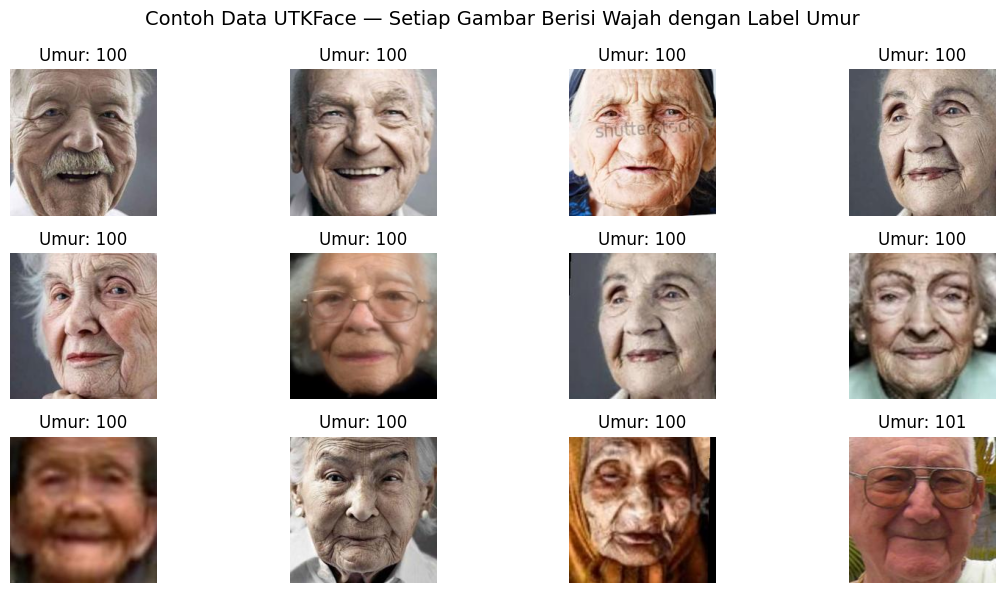

In [ ]:
import matplotlib.pyplot as plt
import os, glob
from PIL import Image

# Ambil 12 gambar acak dari dataset
files = glob.glob("/content/utk/UTKFace/*.jpg")
files = sorted(files)
print(f"Total gambar ditemukan: {len(files)}")

plt.figure(figsize=(12, 6))
for i, f in enumerate(files[:12]):
  # Ambil umur dari nama file
  age = int(os.path.basename(f).split("_")[0])
  img = Image.open(f)

  plt.subplot(3, 4, i + 1)
  plt.imshow(img)
  plt.title(f"Umur: {age}")
  plt.axis("off")

plt.suptitle("Contoh Data UTKFace — Setiap Gambar Berisi Wajah dengan Label Umur", fontsize=14)
plt.tight_layout()
plt.show()

Langkah 5. Siapkan dataset untuk model

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

def parse_age_from_name(fp):
  return int(os.path.basename(fp).split('_')[0])

ages = np.array([parse_age_from_name(f) for f in files], dtype=np.float32)
train_files, test_files, y_train, y_test = train_test_split(files, ages, test_size=0.2, random_state=42)

IMG_SIZE = 160
def load_img(fp, label):
  img = tf.io.read_file(fp)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
  return img / 255.0, label

train_ds = tf.data.Dataset.from_tensor_slices((train_files, y_train)).map(load_img).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((test_files,
y_test)).map(load_img).batch(64)

print("✅ Dataset siap dilatih.")

✅ Dataset siap dilatih.


Langkah 6. Membangun Model dengan Transfer Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Gunakan GPU jika tersedia
print("Hardware:", "GPU" if tf.config.list_physical_devices('GPU') else "CPU")

# Buat arsitektur model
base_model = tf.keras.applications.MobileNetV2(include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet')
base_model.trainable = False # tahap awal: freeze backbone

# Tambahkan head regresi
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)

outputs = layers.Dense(1)(x) # output tunggal: umur
model = tf.keras.Model(inputs, outputs)

# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
model.summary()

Hardware: GPU
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Langkah 7. Melatih Model (Tahap 1 – Frozen)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 55s 128ms/step - loss: 332.1588 - mae: 13.4115 - val_loss: 155.3589 - val_mae: 9.4320 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 44s 45ms/step - loss: 152.1021 - mae: 9.1563 - val_loss: 147.1544 - val_mae: 9.1581 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - loss: 144.9408 - mae: 8.8874 - val_loss: 141.3167 - val_mae: 8.8835 - learning_rate: 0.0010
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 137.6859 - mae: 8.6100 - val_loss: 141.3147 - val_mae: 8.9291 - learning_rate: 0.0010
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 136.9560 - mae: 8.5892 - val_loss: 136.3958 - val_mae: 8.6287 - learning_rate: 0.0010
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 134.5493 - mae: 8.4957 - val_loss: 133.4241 - val_mae: 8.4950 - learning_rate: 0.0010
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - loss: 132.0324 - mae: 8.4126 - val_loss: 135.3758 - va

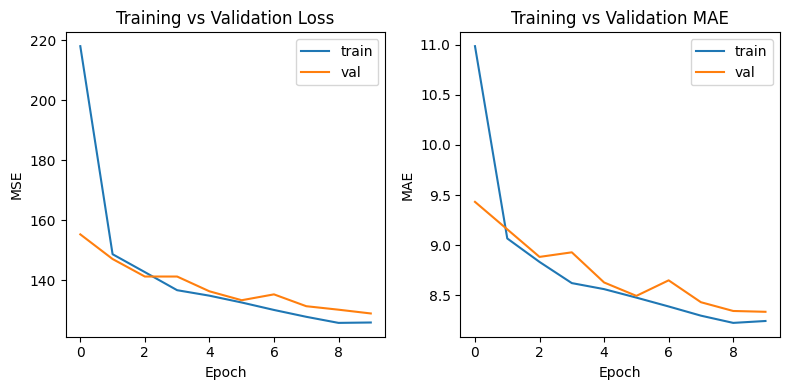

In [ ]:
# Callback untuk pelatihan yang lebih stabil
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-5, monitor='val_loss')
  ]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=cb,
    verbose=1
  )

# Visualisasi perubahan loss dan MAE selama pelatihan:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Training vs Validation Loss')

plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.tight_layout()
plt.show()

Langkah 8. Fine-tuning Backbone (Tahap 2)

Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 190.1873 - mae: 10.1693 - val_loss: 148.4285 - val_mae: 9.2224 - learning_rate: 1.0000e-04
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - loss: 77.3598 - mae: 6.5629 - val_loss: 117.7724 - val_mae: 8.2970 - learning_rate: 1.0000e-04
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - loss: 52.0066 - mae: 5.4392 - val_loss: 124.9349 - val_mae: 8.7223 - learning_rate: 1.0000e-04
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - loss: 37.0482 - mae: 4.6260 - val_loss: 117.0374 - val_mae: 8.2606 - learning_rate: 1.0000e-04
Epoch 5/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - loss: 29.3293 - mae: 4.1401 - val_loss: 107.2418 - val_mae: 7.7022 - learning_rate: 1.0000e-04


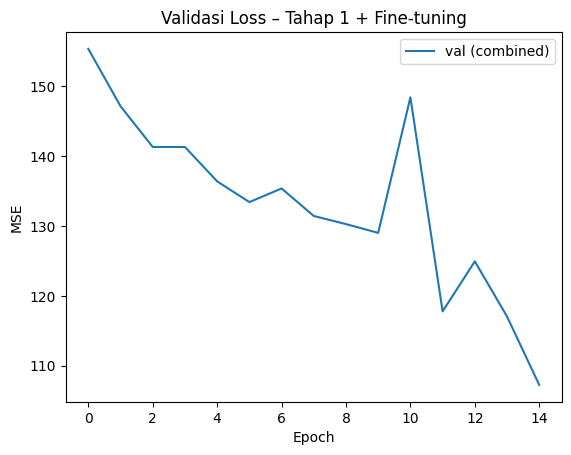

In [ ]:
# Aktifkan kembali sebagian layer terakhir untuk fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
  layer.trainable = False # beku sebagian besar layer

# Recompile dengan learning rate lebih kecil
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='mse', metrics=['mae'])
history_ft = model.fit(train_ds, validation_data=test_ds, epochs=5, callbacks=cb, verbose=1)
# Visualisasi gabungan training dan fine-tuning:
plt.plot(history.history['val_loss'] + history_ft.history['val_loss'],
label='val (combined)')
plt.title("Validasi Loss – Tahap 1 + Fine-tuning")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.show()

Langkah 9. Evaluasi Akhir (MAE, RMSE, R²)

MAE = 7.70 tahun
RMSE = 10.36 tahun
R²	= 0.730


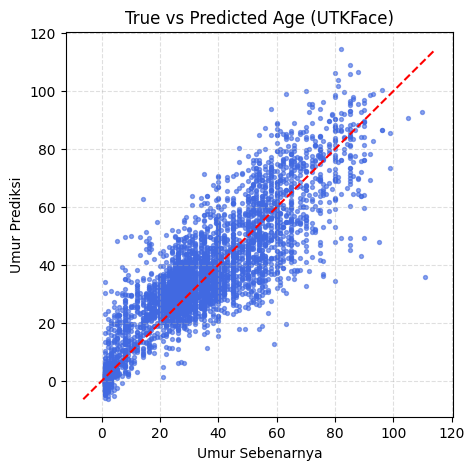

In [ ]:
from math import sqrt

y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for batch in test_ds])
mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(np.mean((y_test - y_pred)**2))
r2 = r2_score(y_test, y_pred)
print(f"MAE = {mae:.2f} tahun")
print(f"RMSE = {rmse:.2f} tahun")
print(f"R²	= {r2:.3f}")

# Plot “umur sebenarnya vs umur prediksi”:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=8, alpha=0.6, color='royalblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("Umur Sebenarnya")
plt.ylabel("Umur Prediksi")
plt.title("True vs Predicted Age (UTKFace)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Langkah 10. Melihat Contoh Prediksi Nyata

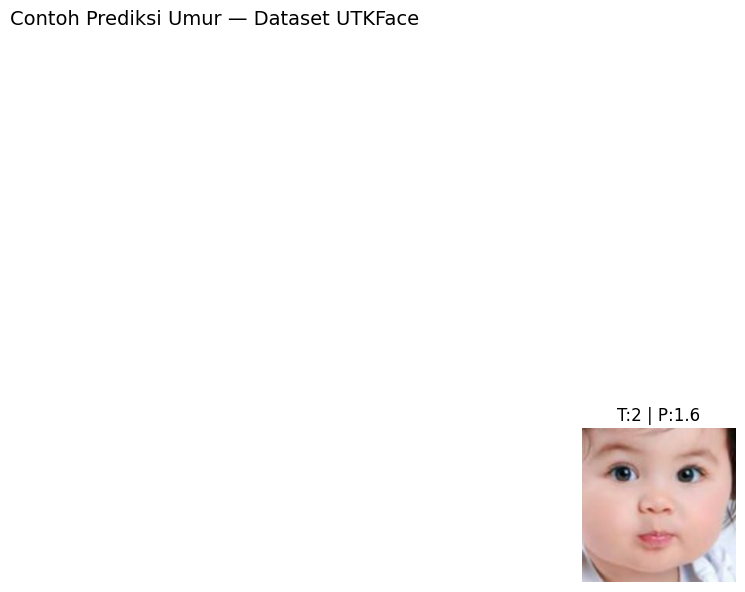

In [ ]:
import random
sample_paths = random.sample(test_files, 12)
plt.figure(figsize=(12,6))
for i, path in enumerate(sample_paths): img = tf.io.read_file(path)
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))/255.0
true_age = int(os.path.basename(path).split('_')[0])
pred_age = model.predict(tf.expand_dims(img, 0), verbose=0).ravel()[0]

plt.subplot(3,4,i+1)
plt.imshow(img.numpy())
plt.title(f"T:{true_age} | P:{pred_age:.1f}")
plt.axis('off')
plt.suptitle("Contoh Prediksi Umur — Dataset UTKFace", fontsize=14)
plt.tight_layout()
plt.show()

# Praktikum 03

Langkah 1. Menyiapkan Kaggle API

In [ ]:
from google.colab import files
files.upload() # pilih kaggle.json dari komputer Anda

import os, shutil
if os.path.exists("kaggle.json"):
  os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
  shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
  os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
  !pip -q install kaggle
  print("✅ Kaggle API siap digunakan.")
else:
  print(" ı. kaggle.json belum ditemukan. Upload terlebih dahulu.")

Saving kaggle.json to kaggle.json
✅ Kaggle API siap digunakan.


Langkah 2. Mengunduh dan Mengekstrak Dataset

In [ ]:
# Unduh dataset Pawpularity (sekitar 800MB)
!kaggle competitions download -c petfinder-pawpularity-score -p /content -q
!unzip -q /content/petfinder-pawpularity-score.zip -d /content/paw
print("✅ Dataset Pawpularity berhasil diekstrak.")

✅ Dataset Pawpularity berhasil diekstrak.


In [ ]:
# Ekstrak file ZIP ke folder /content/paw
!unzip -q /content/petfinder-pawpularity-score.zip -d /content/paw

# Cek hasil ekstrak
!ls /content/paw

replace /content/paw/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
sample_submission.csv  test  test.csv  train  train.csv


Langkah 3. Melihat Contoh Data

In [ ]:
!ls /content/paw
!ls /content/paw/petfinder-pawpularity-score/train | head

sample_submission.csv  test  test.csv  train  train.csv
ls: cannot access '/content/paw/petfinder-pawpularity-score/train': No such file or directory


                                 Id  Subject Focus  Eyes  Face  Near  Action  \
0  0007de18844b0dbbb5e1f607da0606e0              0     1     1     1       0   
1  0009c66b9439883ba2750fb825e1d7db              0     1     1     0       0   
2  0013fd999caf9a3efe1352ca1b0d937e              0     1     1     1       0   
3  0018df346ac9c1d8413cfcc888ca8246              0     1     1     1       0   
4  001dc955e10590d3ca4673f034feeef2              0     0     0     1       0   

   Accessory  Group  Collage  Human  Occlusion  Info  Blur  Pawpularity  \
0          0      1        0      0          0     0     0           63   
1          0      0        0      0          0     0     0           42   
2          0      0        0      1          1     0     0           28   
3          0      0        0      0          0     0     0           15   
4          0      1        0      0          0     0     0           72   

                                                path  
0  /content/p

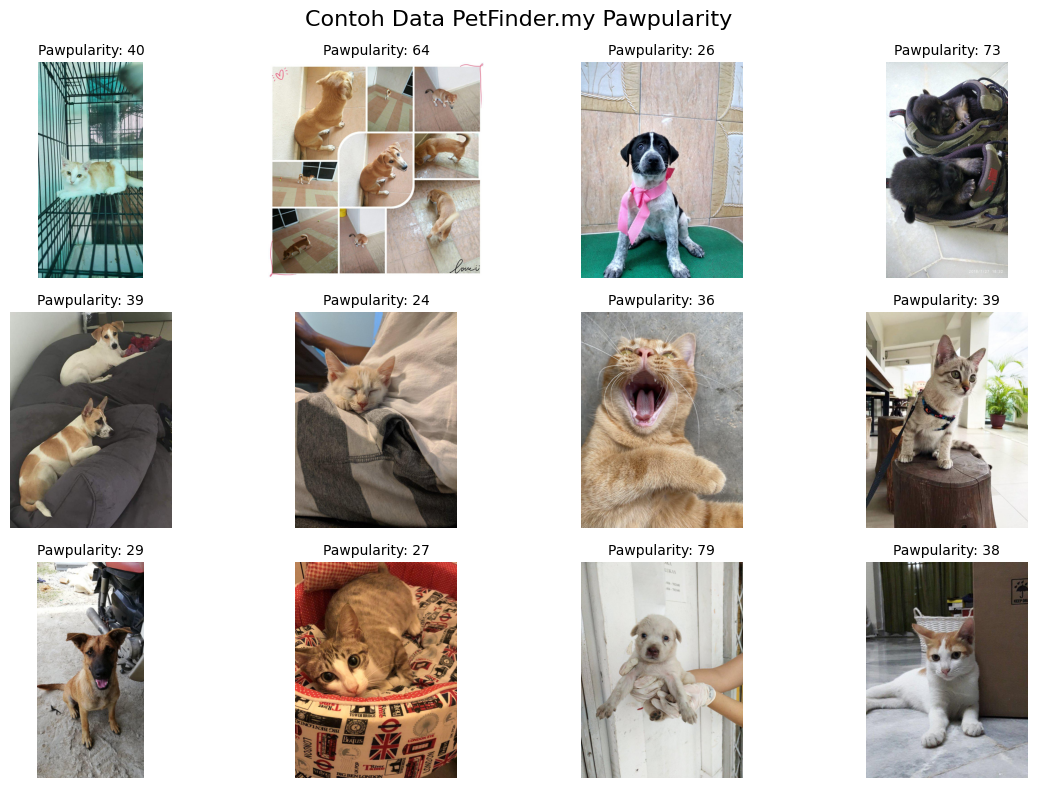

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Muat CSV
df = pd.read_csv('/content/paw/train.csv')
df['path'] = df['Id'].apply(lambda x: f"/content/paw/train/{x}.jpg")

# Tampilkan isi dataframe untuk memastikan
print(df.head())

# Plot 12 gambar acak dengan skor Pawpularity
plt.figure(figsize=(12, 8))
for i, row in enumerate(df.sample(12, random_state=42).itertuples()):
    img = Image.open(row.path)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Pawpularity: {row.Pawpularity}", fontsize=10)
    plt.axis('off')

plt.suptitle("Contoh Data PetFinder.my Pawpularity", fontsize=16)
plt.tight_layout()
plt.show()

Langkah 4. Persiapan Dataset

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

IMG_SIZE = 224
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

def load_image(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
  img = tf.cast(img, tf.float32) / 255.0
  return img, tf.cast(label, tf.float32)

train_ds = tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['Pawpularity']))\
.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)\
.shuffle(4096).batch(64).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_df['path'], val_df['Pawpularity']))\
.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)\
.batch(64).prefetch(tf.data.AUTOTUNE)

print(f"Dataset siap digunakan — {len(train_df)} untuk training, {len(val_df)} untuk validasi.")

Dataset siap digunakan — 7929 untuk training, 1983 untuk validasi.


Langkah 5. Membangun Model (EfficientNetB0)

In [ ]:
from tensorflow.keras import layers, models
base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)

base.trainable = False # freeze sementara

inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs * 255.0)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Langkah 6. Melatih Model

In [ ]:
cb = [
tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=cb, verbose=1)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 100s 478ms/step - loss: 826.7992 - mae: 21.6637 - val_loss: 479.0840 - val_mae: 15.9311 - learning_rate: 0.0010
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 199ms/step - loss: 424.7239 - mae: 15.1680 - val_loss: 429.9778 - val_mae: 15.2835 - learning_rate: 0.0010
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 40s 195ms/step - loss: 388.4165 - mae: 14.5295 - val_loss: 406.0637 - val_mae: 14.8013 - learning_rate: 0.0010
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 41s 232ms/step - loss: 375.9657 - mae: 14.3535 - val_loss: 393.4797 - val_mae: 14.7155 - learning_rate: 0.0010
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 199ms/step - loss: 355.1491 - mae: 14.0917 - val_loss: 383.4304 - val_mae: 14.4827 - learning_rate: 0.0010
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 201ms/step - loss: 345.5470 - mae: 13.7042 - val_loss: 377.5041 - val_mae: 14.2880 - learning_rate: 0.0010
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 201ms/step - loss: 325.3112 - mae: 13.4032 - val_

Langkah 7. Melihat Proses Belajar

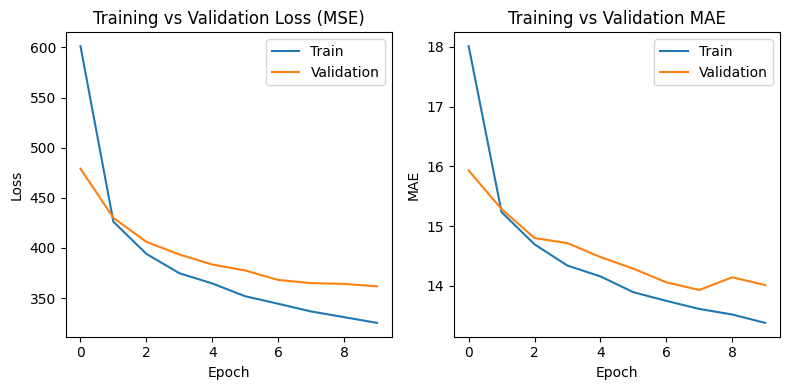

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Training vs Validation Loss (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss");
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Validation')
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE");
plt.legend()
plt.tight_layout()
plt.show()

Langkah 8. Evaluasi Model

MAE = 14.01
RMSE = 19.02
R²	= 0.182


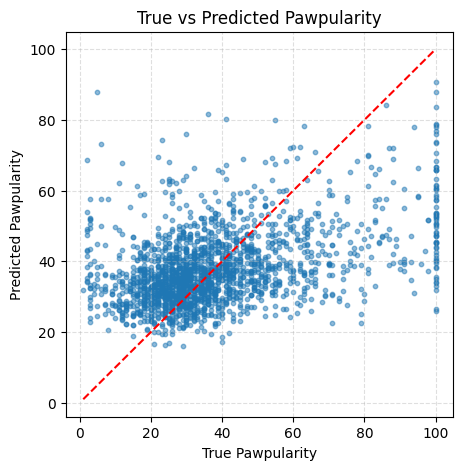

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt
y_true = val_df['Pawpularity'].values.astype(np.float32)
y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for batch in val_ds])

mae = mean_absolute_error(y_true, y_pred)
rmse = sqrt(np.mean((y_true - y_pred)**2))
r2 = r2_score(y_true, y_pred)
print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²	= {r2:.3f}")

# Plot hasil prediksi vs nilai sebenarnya:
plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, s=10, alpha=0.5)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("True Pawpularity")
plt.ylabel("Predicted Pawpularity")
plt.title("True vs Predicted Pawpularity")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Langkah 9. Melihat Contoh Prediksi

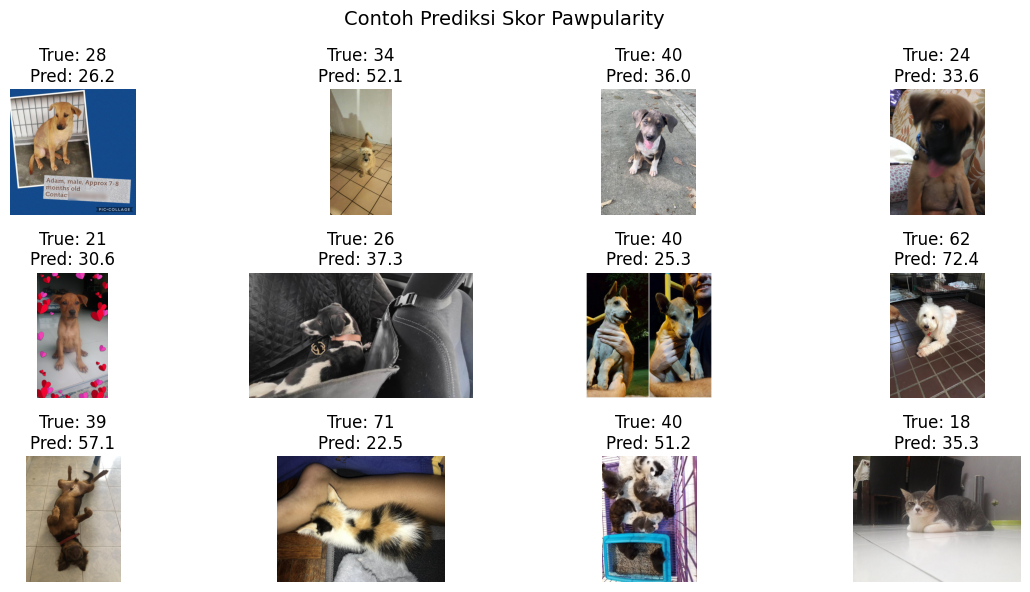

In [ ]:
import random
from PIL import Image

sample_rows = val_df.sample(12, random_state=1)

plt.figure(figsize=(12,6))
for i, row in enumerate(sample_rows.itertuples()):
  img = Image.open(row.path)
  pred = model.predict(tf.expand_dims(load_image(row.path, row.Pawpularity)[0], 0), verbose=0).ravel()[0]
  plt.subplot(3,4,i+1)
  plt.imshow(img)
  plt.title(f"True: {row.Pawpularity}\nPred: {pred:.1f}")
  plt.axis('off')

plt.suptitle("Contoh Prediksi Skor Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

Data Augmentation

In [ ]:
# --- Tambahan: Data Augmentation ---
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(factor=0.2),
], name="augmentation")

EfficientNetB3 vs ResNet50

In [ ]:
# --- Pilih backbone ---
def build_model(backbone="efficientnetb3"):
    IMG_SIZE = 224
    inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)

    if backbone.lower() == "efficientnetb3":
        base = tf.keras.applications.EfficientNetB3(
            include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet')
        preprocess = tf.keras.applications.efficientnet.preprocess_input
    elif backbone.lower() == "resnet50":
        base = tf.keras.applications.ResNet50(
            include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet')
        preprocess = tf.keras.applications.resnet50.preprocess_input
    else:
        raise ValueError("Backbone tidak dikenal. Gunakan 'efficientnetb3' atau 'resnet50'.")

    base.trainable = False

    x = preprocess(x * 255.0)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Contoh penggunaan:
model_efficient = build_model("efficientnetb3")
model_resnet = build_model("resnet50")
model_efficient.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_1 (Multiply)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,264 (42.64 MB)

 Trainable params: 393,729 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

 Eksperimen Anjing vs Kucing

=== Eksperimen Bias Simulatif ===
Jumlah kucing simulasi: 942
Jumlah anjing simulasi: 1041
MAE (Simulasi Kucing): 14.05
MAE (Simulasi Anjing): 13.98


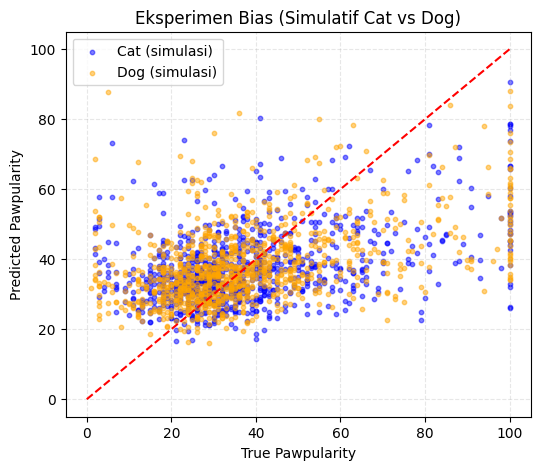

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# --- 1️⃣ Buat label simulatif ---
# Setengah dianggap 'cat', setengah 'dog'
np.random.seed(42)
df['Species'] = np.where(np.random.rand(len(df)) > 0.5, 'cat', 'dog')

# Pisahkan data validasi (pakai val_df yang sama dengan model kamu)
val_df['Species'] = df.loc[val_df.index, 'Species']

# --- 2️⃣ Prediksi seperti biasa ---
y_true = val_df['Pawpularity'].values.astype(np.float32)
y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for batch in val_ds])

val_df['pred'] = y_pred

# --- 3️⃣ Hitung MAE masing-masing 'spesies' ---
cats = val_df[val_df['Species'] == 'cat']
dogs = val_df[val_df['Species'] == 'dog']

mae_cat = mean_absolute_error(cats['Pawpularity'], cats['pred'])
mae_dog = mean_absolute_error(dogs['Pawpularity'], dogs['pred'])

print("=== Eksperimen Bias Simulatif ===")
print(f"Jumlah kucing simulasi: {len(cats)}")
print(f"Jumlah anjing simulasi: {len(dogs)}")
print(f"MAE (Simulasi Kucing): {mae_cat:.2f}")
print(f"MAE (Simulasi Anjing): {mae_dog:.2f}")

# --- 4️⃣ Visualisasi ---
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(cats['Pawpularity'], cats['pred'], s=10, c='blue', alpha=0.5, label='Cat (simulasi)')
plt.scatter(dogs['Pawpularity'], dogs['pred'], s=10, c='orange', alpha=0.5, label='Dog (simulasi)')
plt.plot([0,100],[0,100],'--',color='red')
plt.xlabel("True Pawpularity")
plt.ylabel("Predicted Pawpularity")
plt.title("Eksperimen Bias (Simulatif Cat vs Dog)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Fitur Non-Visual (contoh: Brightness Rata-rata)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

# === 1. Hitung brightness rata-rata untuk setiap gambar ===
brightness_values = []
for path in tqdm(df['path'], desc="Menghitung brightness"):
    img = Image.open(path).convert("L")  # ubah ke grayscale
    brightness = np.mean(np.array(img)) / 255.0  # normalisasi 0–1
    brightness_values.append(brightness)

df['brightness'] = brightness_values
print(df[['Id', 'brightness']].head())

# === 2. Split data ===
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# === 3. Fungsi loader: gambar + fitur non-visual ===
IMG_SIZE = 224

def load_image_with_feature(path, brightness, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    # brightness jadi tensor bentuk (1,)
    brightness = tf.expand_dims(tf.cast(brightness, tf.float32), -1)
    return (img, brightness), tf.cast(label, tf.float32)

# === 4. Buat dataset TensorFlow ===
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df['path'].values, train_df['brightness'].values, train_df['Pawpularity'].values)
).map(load_image_with_feature, num_parallel_calls=tf.data.AUTOTUNE) \
.shuffle(2048).batch(64).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df['path'].values, val_df['brightness'].values, val_df['Pawpularity'].values)
).map(load_image_with_feature, num_parallel_calls=tf.data.AUTOTUNE) \
.batch(64).prefetch(tf.data.AUTOTUNE)

# === 5. Definisikan model CNN + non-visual input ===
def build_multimodal_model(img_size=224, backbone_name="efficientnetb3"):
    img_input = layers.Input(shape=(img_size, img_size, 3), name="image_input")
    brightness_input = layers.Input(shape=(1,), name="brightness_input")

    # Backbone visual
    base_model = tf.keras.applications.EfficientNetB3(
        include_top=False, weights="imagenet", input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False  # freeze backbone sementara

    x = tf.keras.applications.efficientnet.preprocess_input(img_input * 255.0)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Gabungkan fitur non-visual
    concat = layers.Concatenate()([x, brightness_input])
    concat = layers.Dense(256, activation="relu")(concat)
    concat = layers.Dropout(0.3)(concat)
    output = layers.Dense(1, name="output")(concat)

    model = models.Model(inputs=[img_input, brightness_input], outputs=output)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

# === 6. Bangun & ringkas model ===
model = build_multimodal_model()
model.summary()

# === 7. Latih model ===
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Menghitung brightness: 100%|██████████| 9912/9912 [00:57<00:00, 172.47it/s]


                                 Id  brightness
0  0007de18844b0dbbb5e1f607da0606e0    0.586808
1  0009c66b9439883ba2750fb825e1d7db    0.374783
2  0013fd999caf9a3efe1352ca1b0d937e    0.460498
3  0018df346ac9c1d8413cfcc888ca8246    0.615579
4  001dc955e10590d3ca4673f034feeef2    0.507037


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Multiply)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 7, 7,      │ 10,783,535 │ multiply_3[0][0]  │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ brightness_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1537)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ brightness_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    393,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,177,520 (42.64 MB)

 Trainable params: 393,985 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 134s 689ms/step - loss: 918.1531 - mae: 22.9362 - val_loss: 486.8142 - val_mae: 16.1905
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 291ms/step - loss: 443.1143 - mae: 15.4699 - val_loss: 418.1835 - val_mae: 15.1231
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 41s 276ms/step - loss: 393.5226 - mae: 14.7052 - val_loss: 386.6598 - val_mae: 14.5360
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 257ms/step - loss: 361.6559 - mae: 14.1192 - val_loss: 375.9471 - val_mae: 14.3043
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 261ms/step - loss: 340.4312 - mae: 13.7504 - val_loss: 369.1502 - val_mae: 14.0020
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 253ms/step - loss: 327.9881 - mae: 13.4445 - val_loss: 364.7628 - val_mae: 14.0608
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 41s 248ms/step - loss: 325.3233 - mae: 13.4487 - val_loss: 366.2399 - val_mae: 14.2852
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 247ms/step - loss: 312.6339 - mae: 13.2143 - val_loss: 358.6215 - 

# Penugasan

Saving WhatsApp Image 2025-07-17 at 11.49.16.jpeg to WhatsApp Image 2025-07-17 at 11.49.16.jpeg


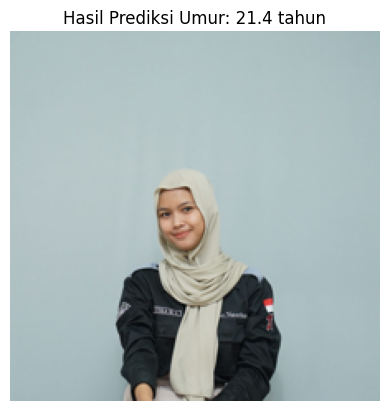

📊 Model memprediksi usia kamu sekitar: 21.4 tahun.


In [ ]:
# --- Uji Prediksi Umur dari Foto Pribadi ---

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1️⃣ Upload foto pribadimu
from google.colab import files
uploaded = files.upload()  # pilih 1 foto wajah kamu (misal: wajahku.jpg)

# 2️⃣ Baca dan ubah ukuran gambar agar sesuai model
img_path = list(uploaded.keys())[0]
img = Image.open(img_path).convert('RGB')
img_resized = img.resize((224, 224))  # sesuaikan dengan ukuran input model kamu
img_array = np.array(img_resized) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # bentuk (1,224,224,3)

# 3️⃣ Prediksi umur
pred_age = model.predict(img_array, verbose=0)[0][0]

# 4️⃣ Tampilkan hasil prediksi
plt.imshow(img_resized)
plt.axis('off')
plt.title(f"Hasil Prediksi Umur: {pred_age:.1f} tahun")
plt.show()

print(f"📊 Model memprediksi usia kamu sekitar: {pred_age:.1f} tahun.")

📸 Silakan upload foto hewan peliharaan kamu (misal: kucingku.jpg)


Saving WhatsApp Image 2025-10-16 at 17.55.35.jpeg to WhatsApp Image 2025-10-16 at 17.55.35.jpeg


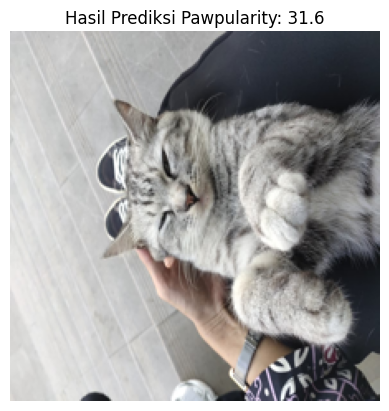

🐾 Model memprediksi skor Pawpularity foto kamu sebesar 31.6


In [ ]:
# --- Uji Model Pawpularity dengan Foto Hewan Peliharaan Sendiri ---
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# 1️⃣ Upload foto hewan peliharaan (misalnya kucing, anjing, kelinci)
print("📸 Silakan upload foto hewan peliharaan kamu (misal: kucingku.jpg)")
uploaded = files.upload()

# 2️⃣ Ambil path file yang diunggah
img_path = list(uploaded.keys())[0]

# 3️⃣ Siapkan gambar untuk prediksi
IMG_SIZE = 224  # sesuaikan dengan ukuran input model
img = Image.open(img_path).convert("RGB")
img_resized = img.resize((IMG_SIZE, IMG_SIZE))
img_array = np.array(img_resized) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 4️⃣ Gunakan model yang sudah dilatih di sesi sebelumnya
pred_score = model.predict(img_array, verbose=0)[0][0]

# 5️⃣ Tampilkan hasil prediksi
plt.imshow(img_resized)
plt.axis('off')
plt.title(f"Hasil Prediksi Pawpularity: {pred_score:.1f}")
plt.show()

print(f"🐾 Model memprediksi skor Pawpularity foto kamu sebesar {pred_score:.1f}")